In [1]:
import pickle
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import copy

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
CLASS_NAMES = ["Human", "AI"]

# **Functions**

In [2]:
def plot_dual_curve(x_vals, train_loss, val_loss, train_acc, val_acc, x_label, model_name):
    fig, ax1 = plt.subplots(figsize=(9, 6))

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("Loss")
    line1 = ax1.plot(x_vals, train_loss, color="tab:red", marker="o", label="Train Loss")
    line2 = ax1.plot(x_vals, val_loss, color="tab:orange", marker="o", linestyle="--", label="Val Loss")
    ax1.tick_params(axis="y")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy")
    line3 = ax2.plot(x_vals, train_acc, color="tab:blue", marker="s", label="Train Accuracy")
    line4 = ax2.plot(x_vals, val_acc, color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
    ax2.tick_params(axis="y")

    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="center right")

    plt.title(f"Training/Validation Loss & Accuracy - {model_name}")
    fig.tight_layout()
    plt.show()

In [3]:
def show_examples(y_true, y_pred, texts, model_name, max_per_group=3):
    examples = {
        ("correct", 0): [], ("correct", 1): [],
        ("incorrect", 0): [], ("incorrect", 1): [],
    }
    class_names_map = {0: "Human", 1: "AI"}

    for i in range(len(y_true)):
        true_label = int(y_true[i])
        pred_label = int(y_pred[i])
        is_correct = (true_label == pred_label)
        key = ("correct" if is_correct else "incorrect", true_label)
        if len(examples[key]) < max_per_group:
            examples[key].append(texts[i])

    print(f"\n{'#'*70}\nExample - {model_name}\n{'#'*70}")
    for (status, label), txts in examples.items():
        print(f"\n{'='*60}")
        print(f"{status.upper()} - class: {class_names_map[label]} ({len(txts)} example)")
        print('='*60)
        for j, text in enumerate(txts, 1):
            print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")

In [4]:
def evaluate_and_report(model, model_name, X_val_vec, y_val, val_texts, is_keras=False, threshold=0.5):
    if is_keras:
        y_proba = model.predict(X_val_vec).flatten()
        y_pred = (y_proba > threshold).astype(int)
    else:
        y_pred = model.predict(X_val_vec)

    print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4))

    conf_mat = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_mat, annot=True, fmt="d", cmap="BuGn",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    show_examples(y_val, y_pred, val_texts, model_name)
    return y_pred

In [5]:
def export_classic_model(model, filename):
    joblib.dump(model, filename)
    print(f"Model saved: {filename}")

def train_with_early_stopping(model, X_train_vec, y_train, X_val_vec, y_val, classes,
                               indices, loss_fn, max_epochs=100, patience=5, model_name=""):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_loss = np.inf
    best_model = None
    epochs_without_improvement = 0
    epoch = 0

    while epoch < max_epochs:
        rng.shuffle(indices)
        model.partial_fit(X_train_vec[indices], y_train[indices], classes=classes)
        epoch += 1

        train_loss = loss_fn(model, X_train_vec, y_train)
        val_loss = loss_fn(model, X_val_vec, y_val)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(accuracy_score(y_train, model.predict(X_train_vec)))
        val_accs.append(accuracy_score(y_val, model.predict(X_val_vec)))

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch} "
                  f"(val loss has not improved for {patience} epochs)")
            break

    if best_model is None:
        best_model = model

    return best_model, train_losses, val_losses, train_accs, val_accs

# **Document level split**

In [6]:
import json

with open("train.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

In [7]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2386
1    2386
Name: count, dtype: int64

Test label distribution:
label
0    674
1    674
Name: count, dtype: int64


In [8]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())

Train shape: (4772, 7)
                                                text  label  \
0  engineering (an existing interface is user req...      0   
1  Ingineria software permite adaptarea unei inte...      1   
2  Dezvoltarea interfețelor utilizator prin abord...      1   
3  duction, automated or not. formation, software...      0   
4  one interactive application to another. In thi...      0   

             AI_used  chunk_no  source  \
0               none         1       1   
1  claude-sonnet-4-5         1       1   
2  claude-sonnet-4-5         2       1   
3               none         2       1   
4               none         3       1   

                                          source_url  year_of_publication  
0  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2008  
1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2008  
2  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2008  
3  https://rochi.utcluj.ro/rrioc/articole

In [9]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf = tfidf_vectorizer.transform(val_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
classes = np.unique(y_train)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)

Train TF-IDF shape: (4772, 20000)
Val TF-IDF shape: (1348, 20000)


## **Logistic Regression**

[Logistic Regression - Document split] Early stopping at epoch 6 (val loss has not improved for 5 epochs)


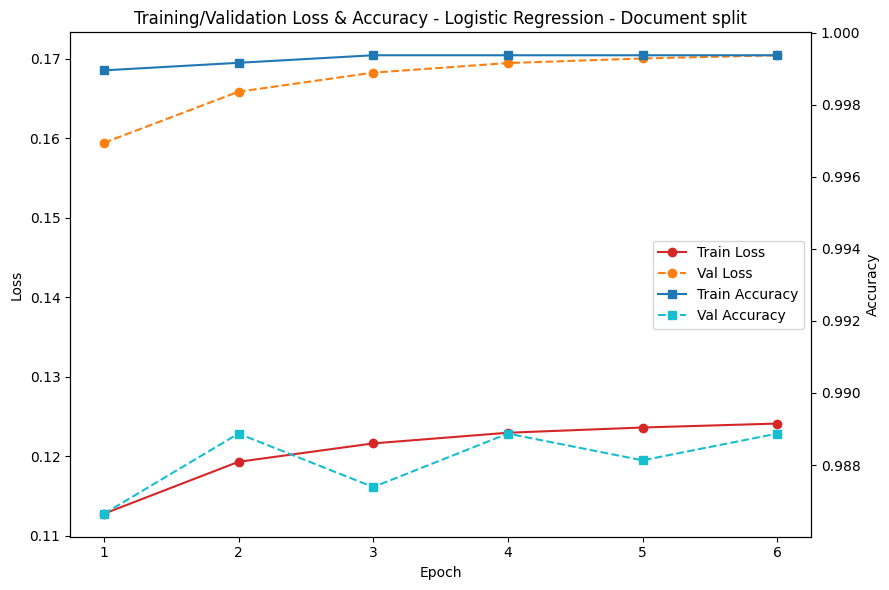

In [10]:
indices = np.arange(X_train_tfidf.shape[0])

def logreg_log_loss(model, X, y):
    return log_loss(y, model.predict_proba(X), labels=[0, 1])

logreg_model, lr_train_losses, lr_val_losses, lr_train_accs, lr_val_accs = train_with_early_stopping(
    SGDClassifier(loss="log_loss", random_state=RANDOM_STATE, warm_start=True),
    X_train_tfidf, y_train, X_val_tfidf, y_val, classes, indices,
    loss_fn=logreg_log_loss, max_epochs=100, patience=5, model_name="Logistic Regression - Document split"
)

plot_dual_curve(range(1, len(lr_train_losses) + 1), lr_train_losses, lr_val_losses,
                lr_train_accs, lr_val_accs, x_label="Epoch", model_name="Logistic Regression - Document split")

              precision    recall  f1-score   support

       Human     0.9754    0.9985    0.9868       674
          AI     0.9985    0.9748    0.9865       674

    accuracy                         0.9866      1348
   macro avg     0.9869    0.9866    0.9866      1348
weighted avg     0.9869    0.9866    0.9866      1348



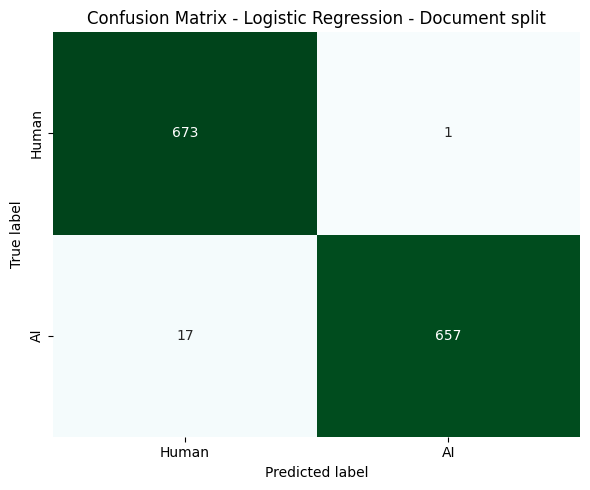


######################################################################
Example - Logistic Regression - Document split
######################################################################

CORRECT - class: Human (3 example)

[1] aplicațiilor distribuite precum Remote Procedure Calls Cuvinte cheie (RPC), Distributed Component Object Model (DCOM), Arhitectură multinivel, componente software, flux Common Object Request Broker Architecture (CORBA), multimedia, sistem multimedia distribuit JavaRMI (Remote Method Invocation) nu a...

[2] ale video și audio și a celor independente de timp: echipamentelor periferice și ale rețelelor de imagini statice, informații în format text, animații; comunicație, • Asigură performanțe bune pentru realizarea • să permită controlul total al datelor multimedia, în prelucrărilor în timp real, ceea ce...

[3] date în vederea extragerii și în baza de date multimedia. utilizării datelor multimedia stocate. Interogarea bazei • Componenta pentru adnotarea fișier

In [19]:
y_pred_lr = evaluate_and_report(logreg_model, "Logistic Regression - Document split", X_val_tfidf, y_val, val_texts)

In [12]:
#model download

export_classic_model(logreg_model, "logreg_model_docsplit.joblib")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer_docsplit.joblib")

from google.colab import files
files.download("logreg_model_docsplit.joblib")
files.download("tfidf_vectorizer_docsplit.joblib")

Model saved: logreg_model_docsplit.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Bi-LSTM**

In [13]:
VOCAB_SIZE = 20000
MAX_LEN = 512
EMBEDDING_DIM = 128

lstm_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
lstm_tokenizer.fit_on_texts(train_texts)

train_sequences = lstm_tokenizer.texts_to_sequences(train_texts)
val_sequences = lstm_tokenizer.texts_to_sequences(val_texts)

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
val_padded = pad_sequences(val_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train padded shape:", train_padded.shape)
print("Val padded shape:", val_padded.shape)

Train padded shape: (4772, 512)
Val padded shape: (1348, 512)


In [14]:
bilstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = bilstm_model.fit(
    train_padded, y_train,
    validation_data=(val_padded, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.8085 - loss: 0.3967 - val_accuracy: 0.9369 - val_loss: 0.1831
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9849 - loss: 0.0551 - val_accuracy: 0.9525 - val_loss: 0.1770
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.9902 - loss: 0.0298 - val_accuracy: 0.9466 - val_loss: 0.2113
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.9973 - loss: 0.0123 - val_accuracy: 0.9540 - val_loss: 0.1884
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9444 - val_loss: 0.3010


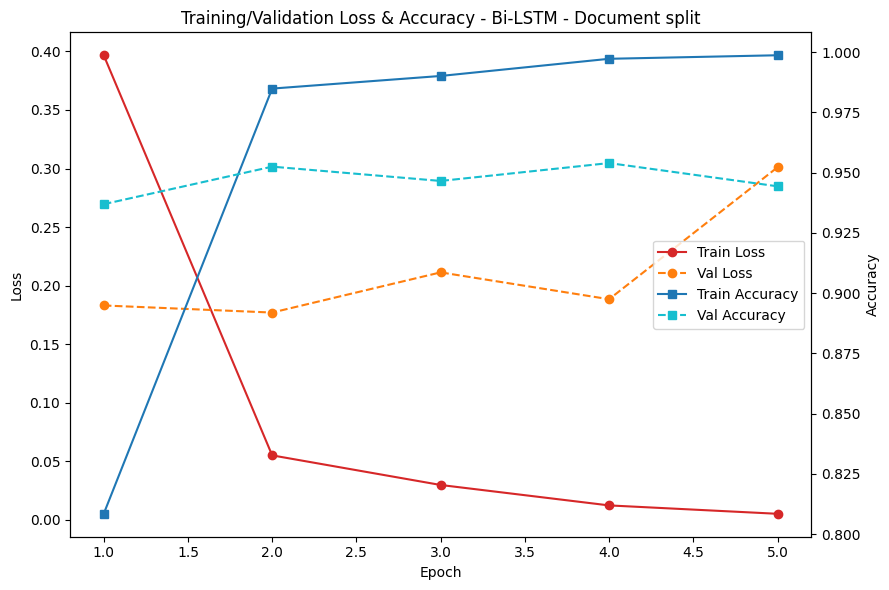

In [16]:
hist = history_lstm.history
epochs_range = range(1, len(hist["loss"]) + 1)

plot_dual_curve(
    list(epochs_range), hist["loss"], hist["val_loss"], hist["accuracy"], hist["val_accuracy"],
    x_label="Epoch", model_name="Bi-LSTM - Document split"
)

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
              precision    recall  f1-score   support

       Human     0.9248    0.9852    0.9540       674
          AI     0.9841    0.9199    0.9509       674

    accuracy                         0.9525      1348
   macro avg     0.9545    0.9525    0.9525      1348
weighted avg     0.9545    0.9525    0.9525      1348



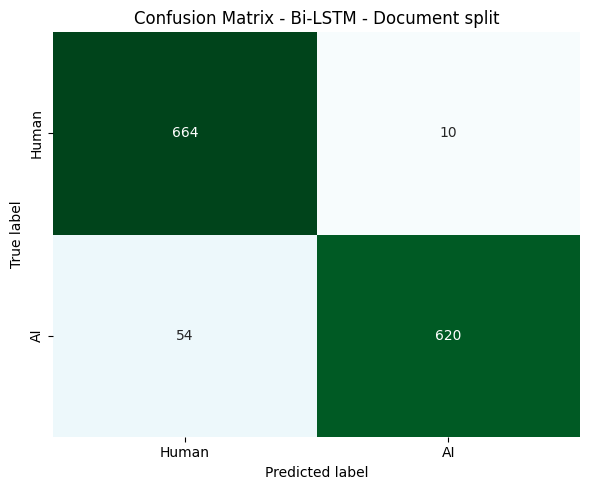


######################################################################
Example - Bi-LSTM - Document split
######################################################################

CORRECT - class: Human (3 example)

[1] aplicațiilor distribuite precum Remote Procedure Calls Cuvinte cheie (RPC), Distributed Component Object Model (DCOM), Arhitectură multinivel, componente software, flux Common Object Request Broker Architecture (CORBA), multimedia, sistem multimedia distribuit JavaRMI (Remote Method Invocation) nu a...

[2] ale video și audio și a celor independente de timp: echipamentelor periferice și ale rețelelor de imagini statice, informații în format text, animații; comunicație, • Asigură performanțe bune pentru realizarea • să permită controlul total al datelor multimedia, în prelucrărilor în timp real, ceea ce...

[3] date în vederea extragerii și în baza de date multimedia. utilizării datelor multimedia stocate. Interogarea bazei • Componenta pentru adnotarea fișierului video d

In [20]:
y_pred_lstm = evaluate_and_report(bilstm_model, "Bi-LSTM - Document split", val_padded, y_val, val_texts, is_keras=True)


In [18]:
#model download

bilstm_model.save("bilstm_model_docsplit.keras")

with open("lstm_tokenizer_docsplit.pickle", "wb") as f:
    pickle.dump(lstm_tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

from google.colab import files
files.download("bilstm_model_docsplit.keras")
files.download("lstm_tokenizer_docsplit.pickle")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>